# Intelligent Methods for Resilience: Household Energy Shifting in DK1

The project investigates how data-driven electricity price signals can strengthen resilience in the Danish electricity grid by encouraging households to shift flexible electricity consumption away from high-price, grid-stressed periods and toward periods of low demand and abundant supply, thereby helping absorb excess electricity when the system struggles to balance production and consumption.

The central idea is straightforward: if households receive clear and actionable recommendations based on when electricity is expected to be cheap or expensive, part of their flexible demand can be shifted in time. This includes electricity use such as electric vehicle charging, dishwashers, washing machines, dryers, and other household consumption that can be delayed or advanced. At the household level, each shift may be small. However, when many households adjust their flexible consumption, these small changes can add up to a meaningful system-level impact, reducing grid pressure, and improving the overall resilience of the electricity system.

## Introduction: Defining Resilience and the Current Grid State in DK1

To evaluate whether the project improves resilience, we first need to describe the current state of the DK1 electricity grid. In this project, the most direct observable signal of grid state is electricity consumption. When consumption is high, more electricity has to be transported through the network at the same time, which increases operational pressure and makes balancing the system more difficult.

Because we do not observe transformer limits or line-level congestion directly, we use historical system consumption as a transparent proxy for stress. The first figure below plots the full historic hourly DK1 consumption series in grey and marks the historical 95th percentile with a red horizontal line. Hours around and above this threshold are treated as peak-load periods. These peaks matter because they reflect moments where the grid operates closer to its upper normal range, increasing the risk of congestion, higher balancing pressure, and faster wear on network assets.


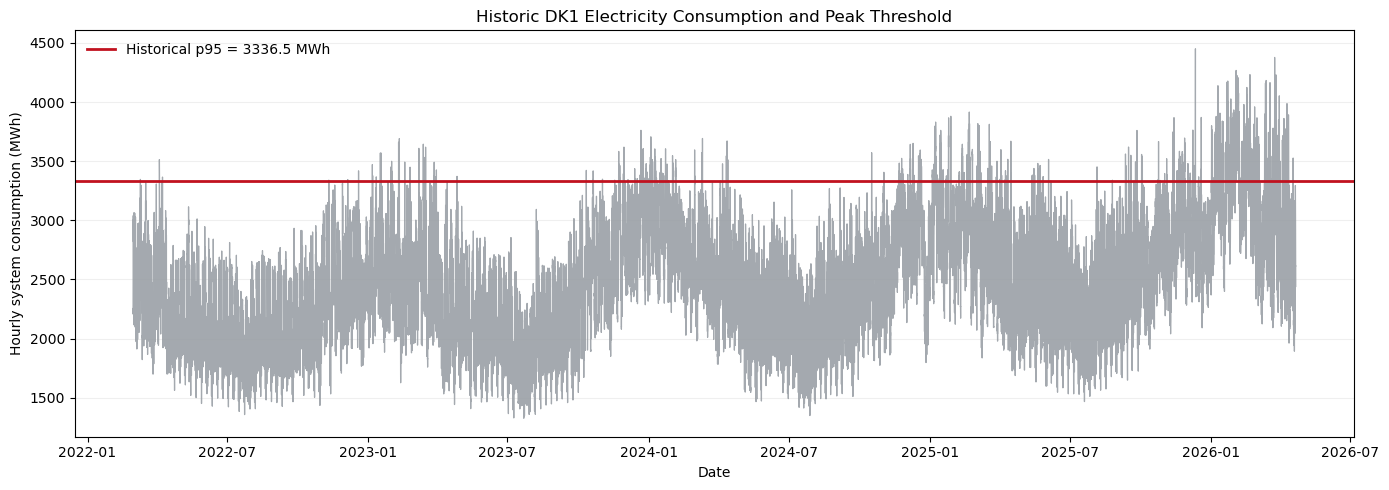

In [2]:
from src.analysis.energy_congestion_analysis import (
    build_grid_state_summary,
    plot_historic_consumption_with_p95,
)

grid_state = build_grid_state_summary()
historic_consumption_figure, _ = plot_historic_consumption_with_p95(grid_state)


The historic series shows that high-load periods are recurring rather than isolated events. It also illustrates how the consumption is increasing over the years, causing more stress hours. To understand the historic consumption trend over the years, the next figure aggregates consumption to monthly totals across the observed years and then counts how many hours in each year exceed the historical 95th percentile.

The monthly bars make the longer-run demand development easier to read than the raw hourly series. The yearly peak-hour bar chart then serves as a compact snapshot of the current grid state: if total consumption and the number of peak hours both rise over time, the need for action that removes or shifts peak loads becomes more urgent.


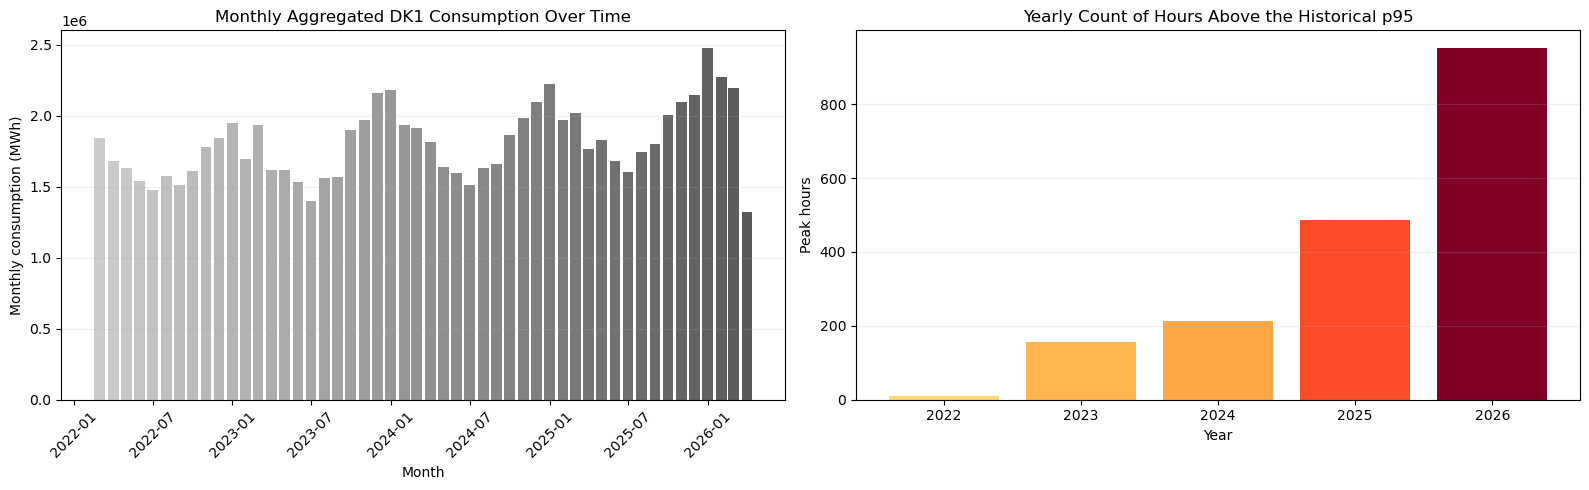

In [3]:
from src.analysis.energy_congestion_analysis import plot_consumption_trend_and_peak_hours

trend_and_peaks_figure, _ = plot_consumption_trend_and_peak_hours(grid_state)


The figures suggest that DK1 is not only characterised by recurring peak-load hours, but also by a broader upward development in electricity consumption over time. This strengthens the case for action: if demand continues to grow while peaks remain frequent, the grid becomes increasingly exposed to stress during already demanding hours. The resilience contribution of the project must therefore be understood as an attempt to improve the timing of consumption, shifting flexible demand away from periods where the system is already under pressure.

To do that in practice, households need more than a description of the current grid state. They need forward-looking signals that indicate when it is likely to be costly or beneficial to consume electricity. This is where forecasting enters the project: after defining the stress problem, the next step is to predict future electricity prices so they can be used as a decision signal for shifting demand.


## Forecast Analysis: Predicting hourly electricity prices 120 hours ahead


The forecast is the central analytical element of the project. Energy shifting is a timing decision: a household can only postpone EV charging, laundry, dishwashing, or heating if it has a credible signal that another hour in the near future will be cheaper or less stressful for the system. In DK1, prices are especially useful because they summarize market scarcity, demand, wind and solar production, interconnector conditions, and other system pressures in one observable hourly signal.

The purpose of the forecast is therefore broader than minimizing prediction error. It creates the forward-looking price profile that the dashboard later turns into recommendations. A good forecast should identify expensive periods, cheap windows, and the uncertainty around those signals, because the recommendation layer should be more confident when the predicted price difference is large and more cautious when the model has historically been noisy at that horizon.


### Data Acquisition: Prices, consumption, weather actuals, and weather forecasts
To forecast DK1 electricity prices, we first need data that describes the price itself and the conditions that influence it. We collect day-ahead prices, observed weather, previous-run weather forecasts, and consumption data. The raw files are saved in `data/` and system-load data that will later be used in the impact simulation.
Data is collected from two public APIs — Energi Data Service for electricity prices and consumption, and Open-Meteo for historical weather actuals and NWP forecasts.

The main data sources are:

- `data/day_ahead_prices_dk1_raw.csv`: hourly day-ahead prices for DK1 from Energi Data Service.
- `data/consumption_dk1_raw.csv`: DK1 electricity consumption used later to measure grid stress and simulate load shifting.
- `data/weather_actuals_raw.csv`: historical weather observations for the DK1 weather location.
- `data/weather_forecasts_raw.csv`: previous-run weather forecasts from Open-Meteo, used to estimate forecast errors.

All raw datasets can be collected with one call:

In [ ]:
from src.data.data_collection import fetch_all

results = fetch_all(start="2021-01-01", end="2026-04-28", price_area="DK1")

As a quick check, we plot prices and actual weather for the same period. This helps confirm that the scraped time series line up and that the weather variables are relevant for price forecasting.

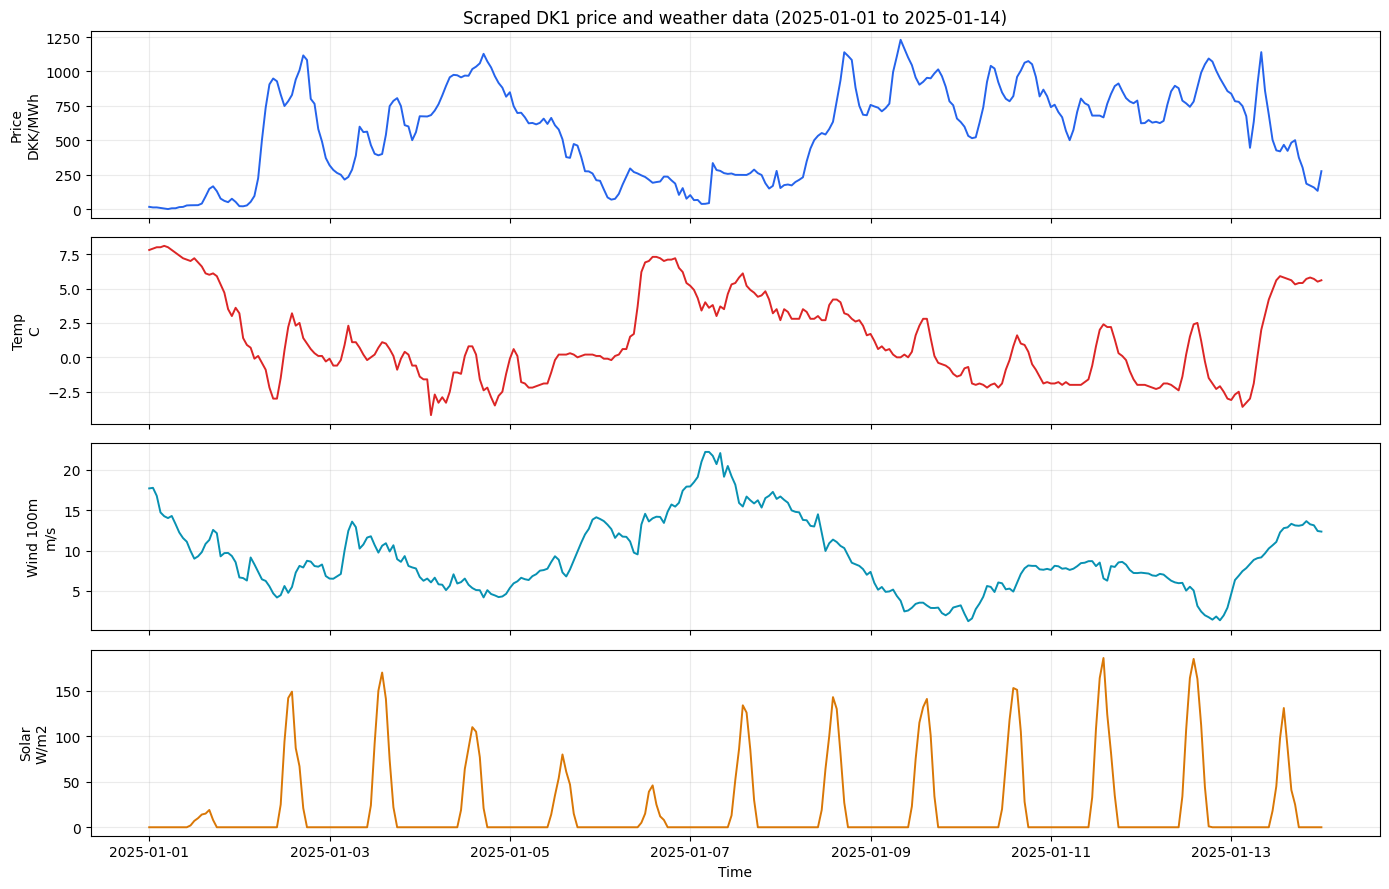

In [1]:
from src.analysis.forecast_analysis import plot_raw_price_and_weather

fig = plot_raw_price_and_weather(start="2025-01-01", end="2025-01-14")

The plot suggests the weather variables are useful predictors of DK1 electricity prices. Price movements appear to line up with changes in wind, temperature, and solar conditions: when wind drops or solar output is low, prices often rise, while stronger wind periods are associated with lower prices. Temperature also seems relevant, as colder periods may increase demand and contribute to higher prices. Overall, the visible movement between price and weather supports the idea that these variables contain predictive information for electricity prices.

### Data Processing: Building a leakage-safe forecast matrix
Before the data can be used for prediction, it must be transformed into the same format the model will see in practice. The key issue is weather data: at forecast time, future realised weather is not known. The model can only rely on weather forecasts.

Real previous-run weather forecasts are only available from 2025 onwards. This period is therefore used to estimate typical forecast errors. These errors are then applied to historical realised weather data to generate forecast-like weather inputs for the full historical period.

This step is important because using historical actual weather directly as a future predictor would create data leakage. The model would then learn from information that would not have been available at the time of making a real forecast. By replacing future actual weather with forecast-like inputs, the dataset better reflects the real forecasting situation. The error distribution for each variable can be found in 
- `data/weather_error_distributions.csv`:

For each issue time, the processing script 
`data/data_processing.py` creates 120 rows , corresponding to forecast horizons from 1 to 120 hours ahead. Each row contains the issue time, target time, horizon, forecast-like weather variables, calendar variables, and price lags known at the issue time. The target variable is the realised day-ahead price at the target time.

The result is a leakage-safe forecast matrix that mirrors the information structure of the production dashboard: only information known at the issue time is used to forecast prices at later target times

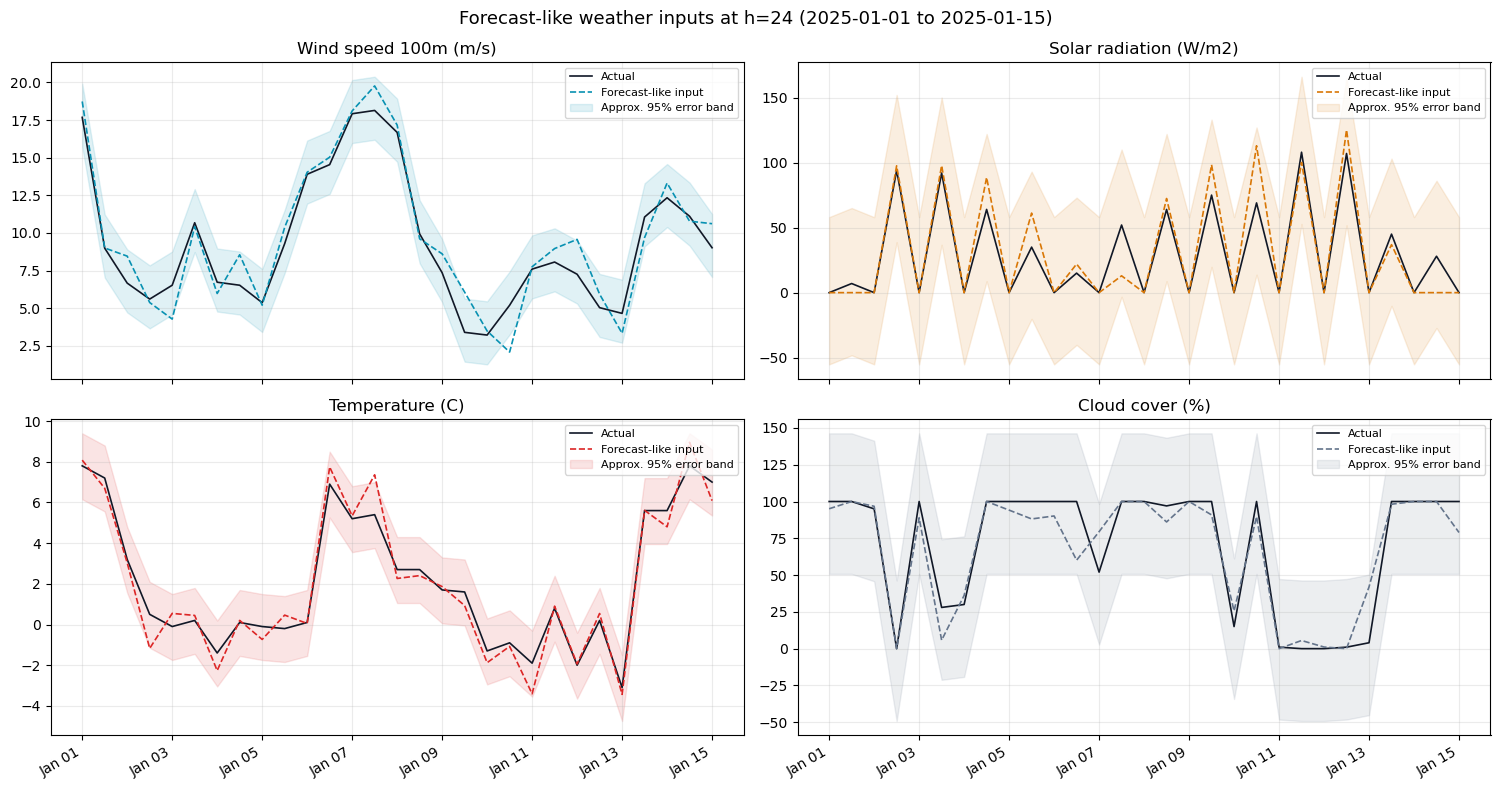

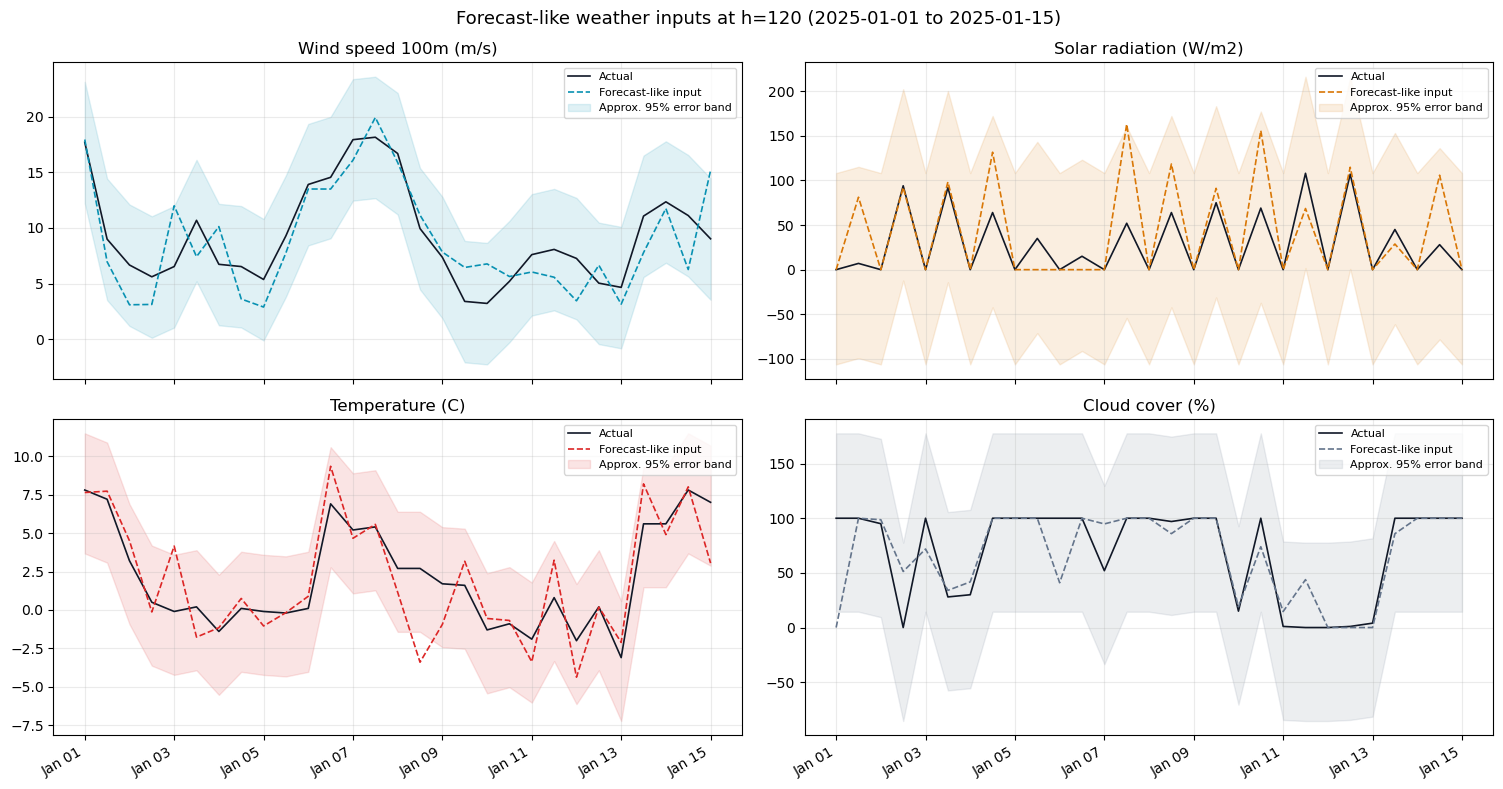

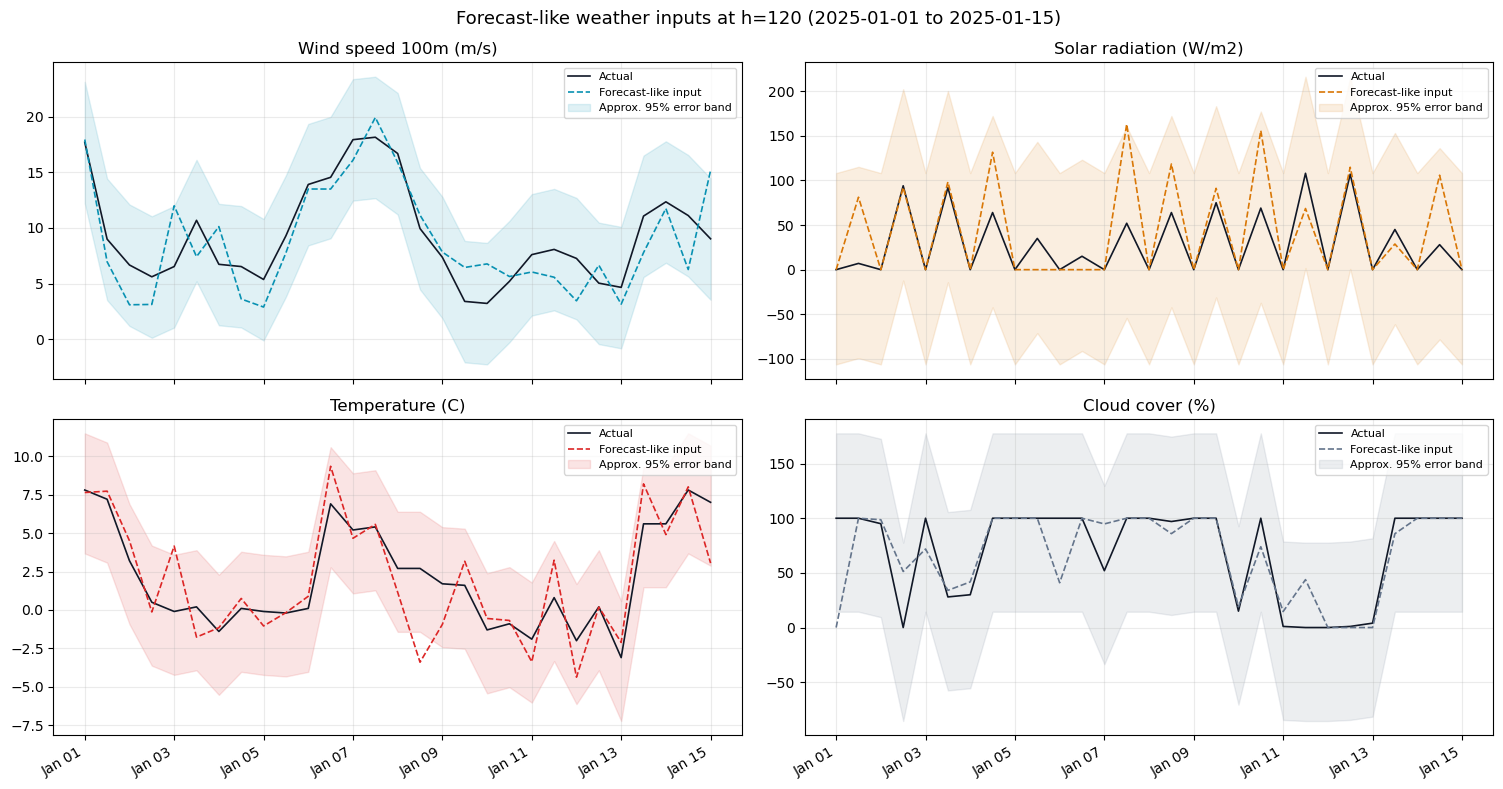

In [17]:
from src.analysis.forecast_analysis import plot_weather_forecast_grid

plot_weather_forecast_grid(horizon_hours=24)
plot_weather_forecast_grid(horizon_hours=120)


The weather plots show why the processing step is necessary. At a 24-hour horizon, the generated forecast-like weather variables generally follow the realised weather closely. At a 120-hour horizon, the deviations and uncertainty bands are wider. This is expected: longer weather forecasts are harder, and that uncertainty can propagate into electricity-price forecasts.

The implication for the recommender system is practical. A five-day forecast can still be valuable, but recommendations based on later horizons should be interpreted with more caution than recommendations based on the next few hours. This is one reason the forecast section evaluates both point accuracy and residual uncertainty by horizon.


To get an initial understanding of which variables may be useful for forecasting future DK1 prices, we examine their Pearson correlation with the target variable at the 120-hour horizon. This allows us to assess the strength and direction of the linear relationship between each feature and the future price before fitting the forecasting models.

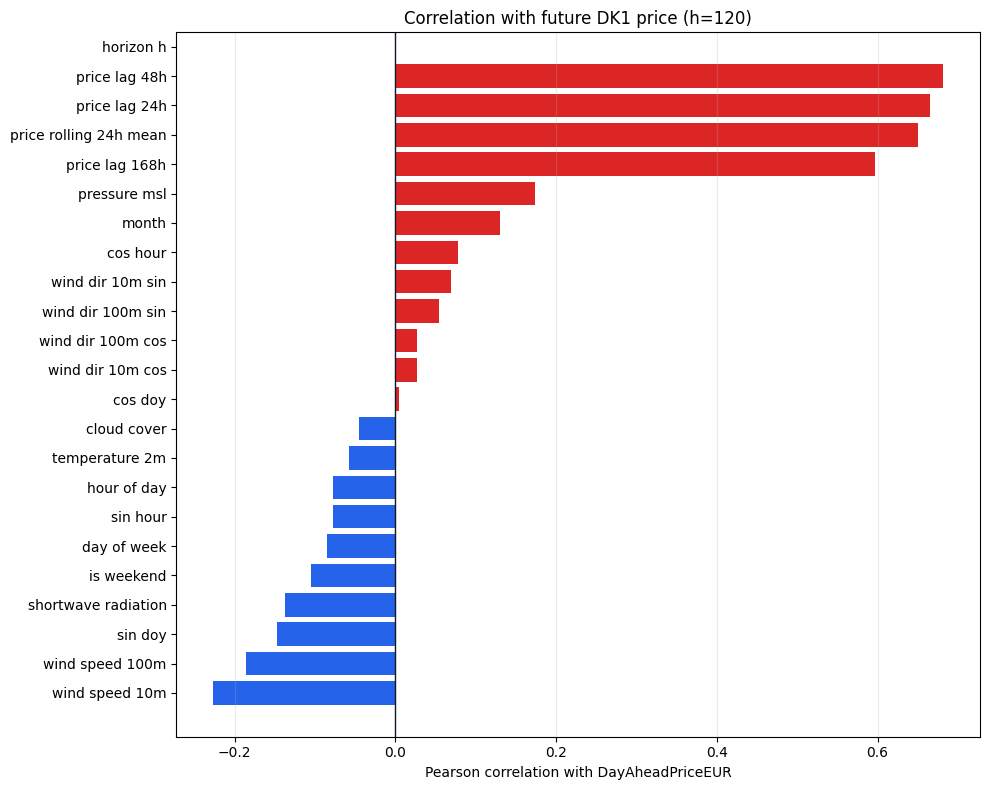

In [7]:
from src.analysis.forecast_analysis import plot_weather_price_correlation

fig = plot_weather_price_correlation(correlation_horizon=120)


The correlation plot is not intended as a causal analysis, but rather as a sanity check. It helps assess whether the forecasted weather variables and lagged price variables contain statistical information about the future price target. However, some relationships are likely to be nonlinear or dependent on market conditions. For example, higher wind production can reduce prices by increasing renewable supply, but the magnitude of this effect depends on demand, interconnector flows, and the overall market situation

In [8]:
from src.analysis.forecast_analysis import preview_feature_matrix_24h

preview_feature_matrix_24h()


,issue_time,target_time,horizon_h,y_future_price_eur_mwh,fcst_wind_speed_100m,fcst_shortwave_radiation,fcst_temperature_2m,fcst_cloud_cover,price_lag_24h,price_lag_168h,hour_of_day,day_of_week
23,2021-01-08 00:00:00,2021-01-09 00:00:00,24,50.669998,3.3802,0.0000,-2.2731,100.0000,43.080002,50.869999,0,5
143,2021-01-08 12:00:00,2021-01-09 12:00:00,24,67.010002,5.1248,53.7726,0.8902,35.9286,84.709999,50.779999,12,5
263,2021-01-09 00:00:00,2021-01-10 00:00:00,24,38.840000,9.9475,0.0000,-0.2028,74.9634,49.310001,46.689999,0,6
383,2021-01-09 12:00:00,2021-01-10 12:00:00,24,44.759998,5.6550,41.0278,2.5679,100.0000,99.910004,55.950001,12,6
503,2021-01-10 00:00:00,2021-01-11 00:00:00,24,44.900002,6.2067,0.0000,0.9379,95.2886,50.669998,46.110001,0,0
623,2021-01-10 12:00:00,2021-01-11 12:00:00,24,43.330002,11.5549,45.0693,6.0287,69.9897,67.010002,25.870001,12,0
743,2021-01-11 00:00:00,2021-01-12 00:00:00,24,18.959999,10.0843,0.0000,3.5313,100.0000,38.840000,24.660000,0,1
863,2021-01-11 12:00:00,2021-01-12 12:00:00,24,50.099998,5.8798,0.0000,1.9237,100.0000,44.759998,52.070000,12,1


The preview above shows the final learning problem for a 24-hour horizon. Each row links information available at `issue_time` to the realised price at `target_time`. The price lag features, such as the 24-hour and 168-hour lags, are based only on prices observed before the forecast is issued. The weather columns are forecast-like values, not perfect future actuals. This gives the model a realistic basis for producing a 120-hour forecast profile.


This structure matters because the model must resemble a real recommender system. At the moment a recommendation is issued, the system knows recent prices, calendar information, and weather forecasts. It does not know future realised weather or future realised prices.

`data/model_dataset.parquet`: the final model matrix used by the XGBoost forecast.


In [3]:
from src.analysis.forecast_analysis import preview_forecast_source_data

preview_forecast_source_data()


,data,file,rows,time_range,columns,role
0,Day-ahead prices,data\day_ahead_prices_dk1_raw.csv,"61,775",2021-01-01 to 2026-04-28,"TimeUTC, TimeDK, PriceArea, DayAheadPriceEUR, ...",Target price series from Energi Data Service.
1,Consumption,data\consumption_dk1_raw.csv,"958,075",2022-03-01 to 2026-04-21,"Date, TimeUTC, TimeDK, PriceArea, GridArea, Gr...",System load series used later in the impact si...
2,Weather actuals,data\weather_actuals_raw.csv,"46,680",2021-01-01 to 2026-04-29,"TimeDK, region, Latitude, Longitude, Elevation...",Historical observed weather for the DK1 weathe...
3,Weather forecasts,data\weather_forecasts_raw.csv,"46,680",2021-01-01 to 2026-04-29,"TimeDK, region, Latitude, Longitude, Elevation...",Open-Meteo previous-run forecasts used to esti...
4,Weather error distributions,data\weather_error_distributions.csv,40,h=24 to h=120,"forecast_variable, actual_variable, horizon_ho...",Forecast-error summary by variable and horizon.
5,Model matrix,data\model_dataset.parquet,"463,846",2021-01-08 to 2026-04-28,"region, issue_time, target_time, horizon_h, ho...","Forecast-like weather, calendar features, pric..."


### XGBoost Forecasting Model

The forecasting model is implemented in `src/models/XG_Boost_full_Res.py`. The script trains five separate XGBoost regression models, one for each forecast day:

- Day 1: horizons 1-24 hours ahead.
- Day 2: horizons 25-48 hours ahead.
- Day 3: horizons 49-72 hours ahead.
- Day 4: horizons 73-96 hours ahead.
- Day 5: horizons 97-120 hours ahead.

This design is useful because short-horizon and long-horizon forecasts have different error structures. The next few hours are usually more anchored by recent prices and near-term weather forecasts, while later horizons are more uncertain and depend more on broader calendar and weather-pattern information. Splitting the model by forecast day lets each XGBoost regressor specialize in one part of the 120-hour horizon.

XGBoost is a good choice for this project because electricity prices are tabular, nonlinear, and interaction-heavy. Gradient-boosted trees can capture threshold effects, such as very low wind or peak-hour demand, without requiring all interactions to be manually specified. The method also works well with mixed calendar, lag, and weather features, requires little feature scaling, and can later be inspected using feature importance and SHAP. Finally, the model is fast enough to retrain and evaluate with walk-forward validation, which is important for a time-series forecasting problem.

Validation is performed with an expanding walk-forward split. The first 12 months are used for training, the next 3 months are used for testing, and the training window then expands forward. This preserves the time order of the data and produces out-of-sample residuals that can be used both for accuracy metrics and uncertainty estimation.


In [ ]:
from IPython.display import display

from src.analysis.forecast_analysis import (
    make_forecast_metrics_table,
    plot_forecast_model_outputs,
    preview_xgboost_design,
)

display(preview_xgboost_design())
plot_forecast_model_outputs(unit="dkk_kwh")

make_forecast_metrics_table(unit="dkk_kwh").style.format(
    {
        "n_predictions": "{:,}",
        "MAE (DKK/kWh)": "{:.3f}",
        "RMSE (DKK/kWh)": "{:.3f}",
        "Bias (DKK/kWh)": "{:+.3f}",
        "Residual std (DKK/kWh)": "{:.3f}",
        "P90 abs error (DKK/kWh)": "{:.3f}",
    }
)


The results should be read in two ways. First, the walk-forward fold plot shows whether performance is stable over time. Large errors around crisis or high-volatility periods are expected in electricity markets, because prices can spike when scarcity, fuel prices, outages, or interconnector conditions change abruptly. Second, the horizon plot shows how error develops across the 120-hour forecast window. This is directly relevant for recommendations: a predicted saving tomorrow is usually a stronger signal than a similarly sized predicted saving five days ahead if the five-day residual spread is much larger.

The forecast does not need to be perfect to be useful. For household flexibility, the key question is whether the model can rank future hours well enough to identify cheaper and more expensive windows. However, the size of the forecast error determines how forcefully the dashboard should communicate a recommendation. Small expected savings inside a wide error band should be framed cautiously, while large savings that exceed historical uncertainty can support a stronger recommendation.


### Price Prediction Uncertainty: Residual-based forecast bands

The lecture material on prediction uncertainty emphasizes that a prediction should not be treated only as a single expected value. A future price is uncertain, so a decision-support system should also communicate the spread around the point forecast. In this project we estimate uncertainty from the walk-forward residuals, because those residuals measure how wrong the model was on data that was not used for fitting.

For each out-of-sample prediction we compute the signed residual

$$
e_h = \hat{y}_h - y_h,
$$

where $\hat{y}_h$ is the predicted price for horizon $h$ and $y_h$ is the realised price. We then group residuals by `horizon_h` and calculate a horizon-specific standard deviation, $\sigma_h$. The simple forecast band used here is

$$
\hat{y}_h \pm \sigma_h.
$$

The diagnostics below use residuals from 1 January 2023 onward. This keeps the uncertainty estimate focused on the post-energy-crisis market regime, rather than letting the extreme 2022 volatility dominate the current dashboard bands. The band should be interpreted as an empirical prediction-uncertainty measure, not as a guarantee that prices will fall inside the interval.


In [ ]:
from src.analysis.forecast_analysis import (
    make_uncertainty_summary_table,
    plot_residual_diagnostics,
    plot_single_forecast_with_uncertainty,
)

plot_single_forecast_with_uncertainty(unit="dkk_kwh")
plot_residual_diagnostics(unit="dkk_kwh")

make_uncertainty_summary_table(unit="dkk_kwh").style.format(
    {
        "Mean residual sigma (DKK/kWh)": "{:.3f}",
        "Max residual sigma (DKK/kWh)": "{:.3f}",
        "Mean P90 abs error (DKK/kWh)": "{:.3f}",
        "Mean bias (DKK/kWh)": "{:+.3f}",
        "residual_sample_size": "{:,}",
    }
)


Uncertainty is essential for the recommendation layer. The dashboard should not only ask whether a future hour is predicted to be cheaper, but whether the predicted difference is large relative to the model's historical error at that horizon. If the cheapest future window is only slightly below the current price and the residual band is wide, the recommendation should be softer: waiting may help, but the signal is uncertain. If the predicted price drop is much larger than the residual spread, the forecast can reinforce a stronger recommendation to delay flexible consumption.

The same logic applies to warnings about expensive periods. A high-price warning is more credible when the predicted expensive block remains expensive even after accounting for historical forecast error. In this way, uncertainty does not weaken the project. It makes the forecast more decision-ready by showing when the model signal is strong enough to act on and when household advice should be framed as cautious rather than definitive.


## Explainable AI: SHAP and LIME for a decision-support forecast

The forecasting model produces a 120-hour price profile for DK1. The recommendation layer then translates that profile into timing advice: whether a household should consume now to avoid an expensive period or wait for a cheaper window. Explainable AI sits between these two steps. Its purpose is to show which input variables are driving the predicted prices that later become household recommendations.

In this project, XAI has three roles. First, it checks whether the XGBoost models rely on plausible electricity-market drivers such as recent price levels, forecasted wind, solar radiation, temperature, cloud cover, and calendar effects. Second, it supports the dashboard by turning the model from a black box into an inspectable forecast engine. Third, it strengthens the later impact analysis: if simulated load shifting depends on model-based price signals, we should understand what produced those signals before interpreting the estimated system benefit.


In [10]:
import joblib

from src.analysis.explainable_ai import (
    OUTPUT_DIR,
    make_dashboard_shap_summary,
    plot_feature_importance,
    plot_lime_explanations,
    plot_shap_explanations,
)

final_models = joblib.load(OUTPUT_DIR / "final_day_models.joblib")


We start with XGBoost feature importance as a coarse global view. The model is split into five day-specific regressors, so the plot shows whether the short-horizon and long-horizon forecasts depend on similar drivers or whether the dominant predictors change across the 120-hour forecast window.


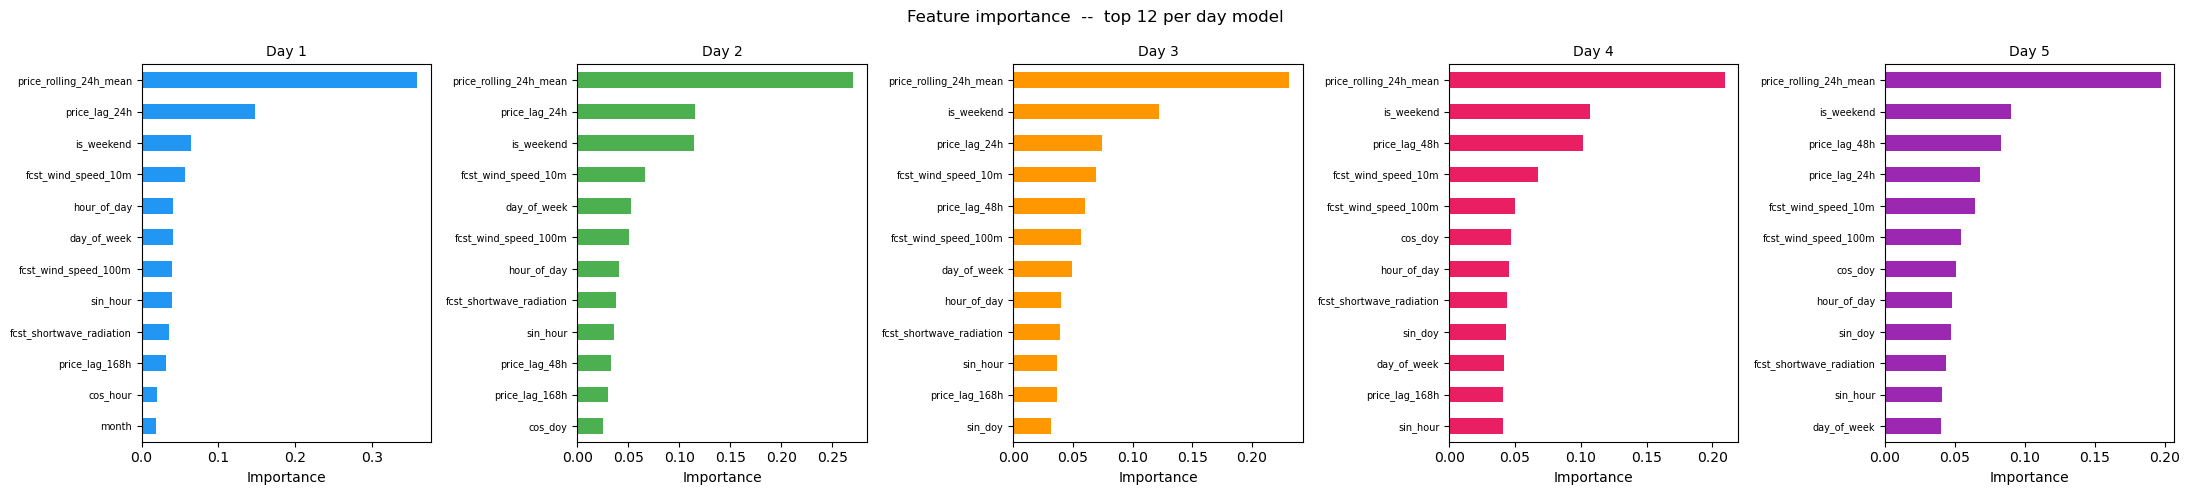

In [11]:
plot_feature_importance(final_models)


Feature importance is useful as an entry point, but it does not show whether a feature pushes the forecast up or down. It can also blur correlated drivers. We therefore use SHAP as the main global explanation method. SHAP decomposes each forecast into additive feature contributions, which is useful when the dashboard recommends a timing decision and we want to understand why a cheap or expensive window appears in the forecast.


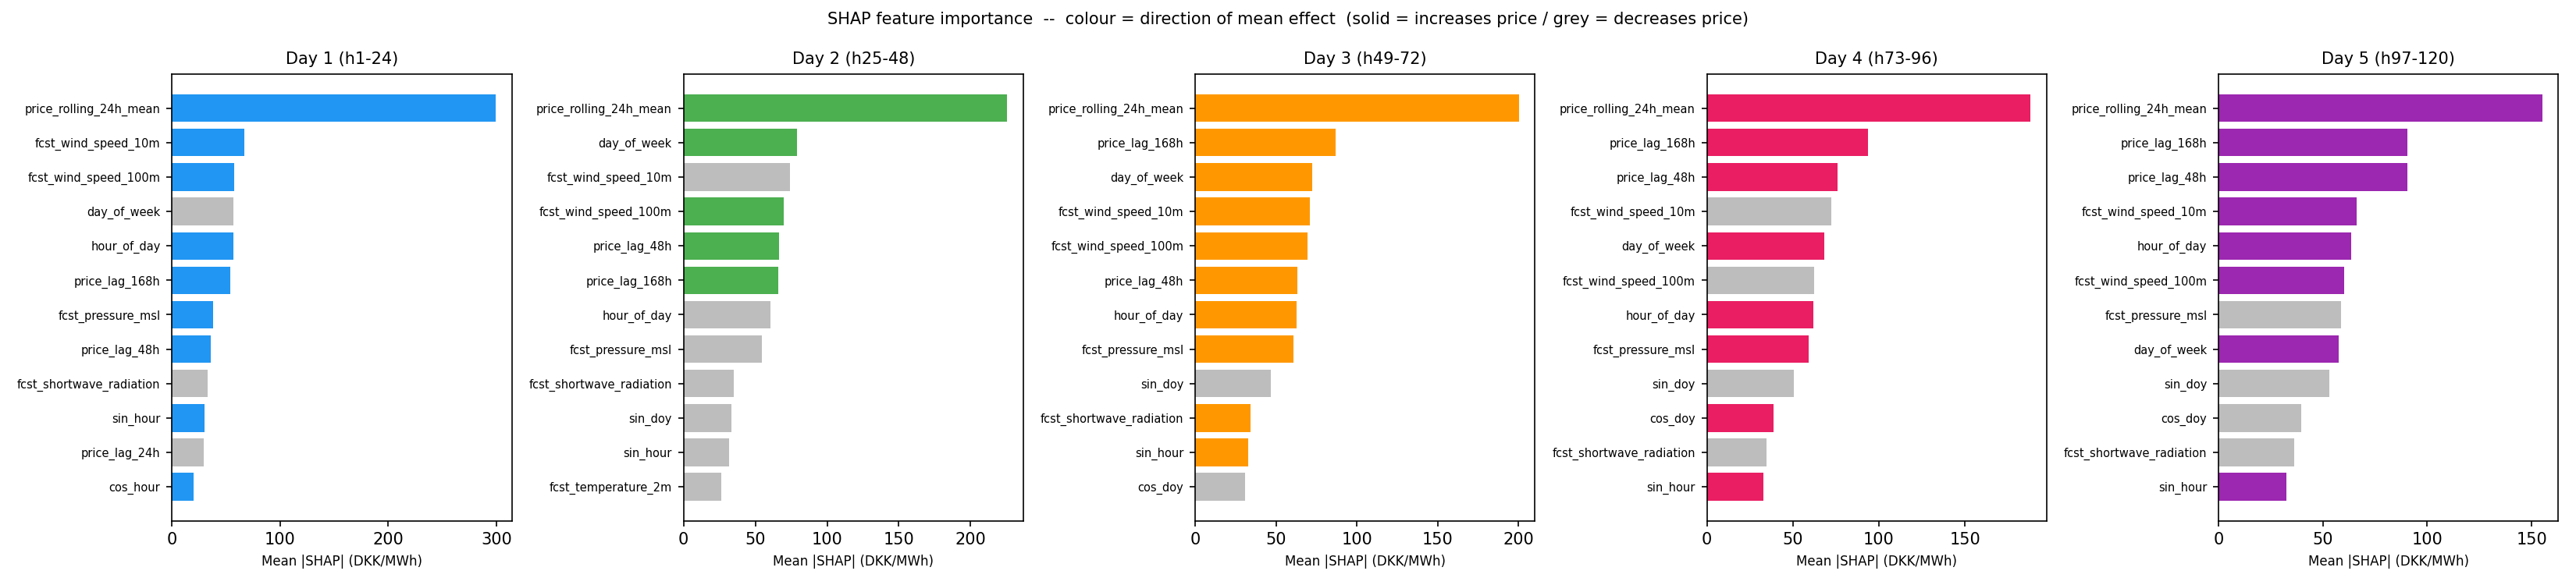

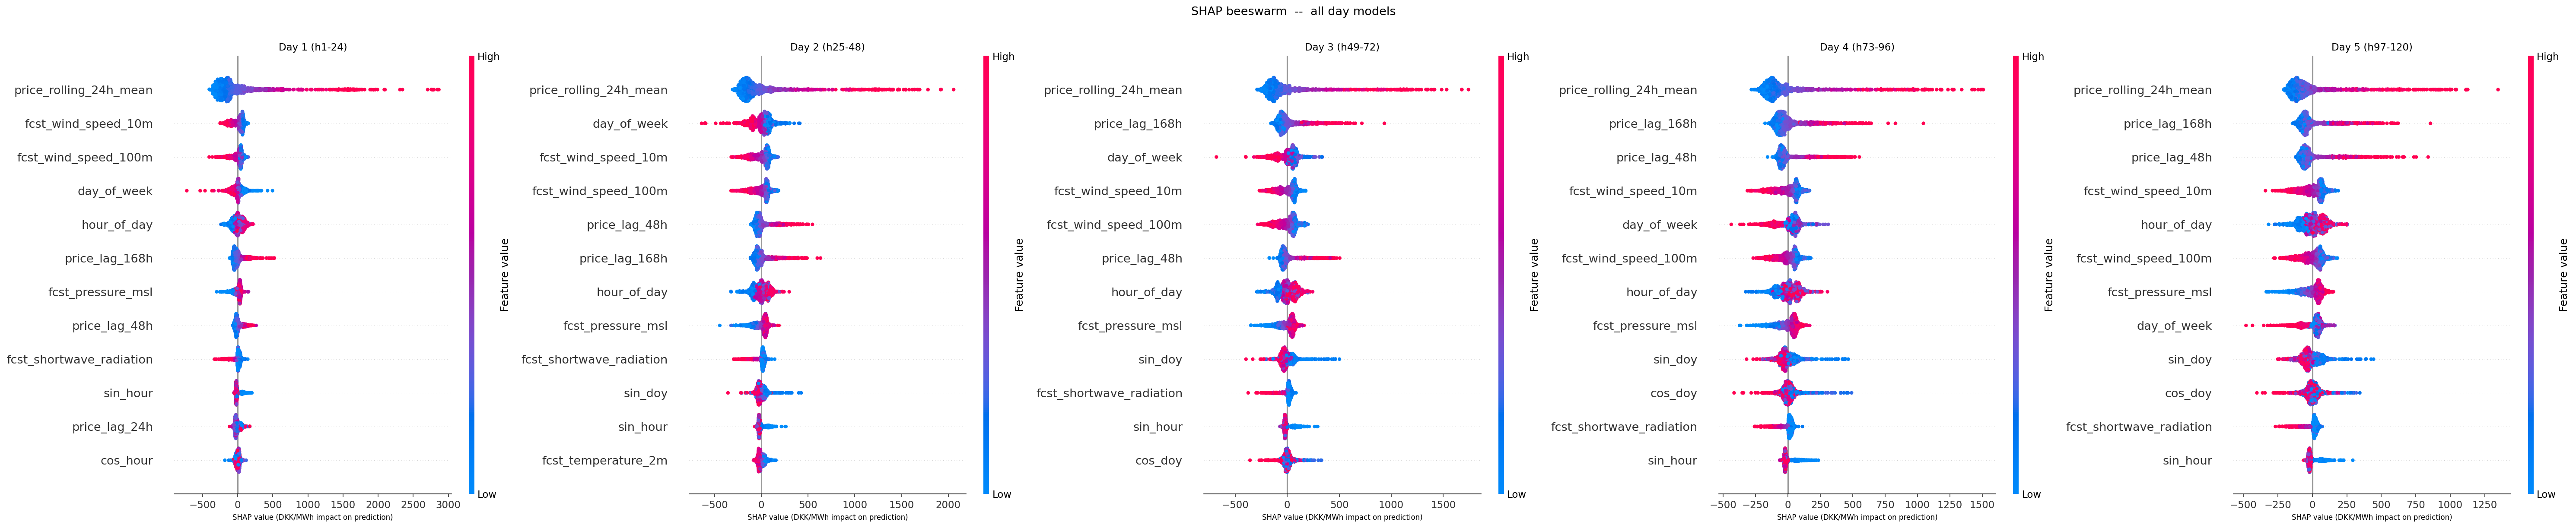

In [12]:
plot_shap_explanations(width=1200)


The SHAP bar plot ranks features by their average absolute contribution to the price forecast, while the beeswarm plot shows the distribution and direction of effects across many sampled forecasts. This distinction matters for recommendations: a feature may be important because high values consistently lift predicted prices, because low values depress prices, or because the effect changes across market regimes.

For the project objective, households do not need to read SHAP plots before using the app. The value is that SHAP gives the project team and dashboard a transparent link between the forecast signal and the market story behind it. A recommendation to wait should be traceable to sensible drivers such as renewable availability, recent price persistence, demand-sensitive weather, or time-of-day effects rather than an arbitrary model artifact.


In [13]:
dashboard_shap_summary = make_dashboard_shap_summary(top_n=8)
dashboard_shap_summary.style.format(
    {
        "mean_abs_shap_dkk_kwh": "{:.4f}",
        "mean_signed_shap_dkk_kwh": "{:+.4f}",
        "sample_mean_feature_value": "{:.2f}",
    }
)


,feature,mean_abs_shap_dkk_kwh,mean_signed_shap_dkk_kwh,sample_mean_feature_value
0,price_rolling_24h_mean,0.3028,+0.0493,116.72
1,fcst_wind_speed_10m,0.0677,+0.0029,4.44
2,day_of_week,0.0601,-0.0055,3.22
3,fcst_wind_speed_100m,0.0576,+0.0010,7.51
4,price_lag_168h,0.0570,+0.0076,103.19
5,hour_of_day,0.0543,+0.0034,11.69
6,fcst_pressure_msl,0.0372,+0.0042,1013.88
7,price_lag_48h,0.0368,+0.0116,102.40


The table above uses the same Day 1 SHAP export that is loaded by `dashboard.py` from `outputs/model/shap_day1_values.parquet` and `outputs/model/shap_day1_features.parquet`. This allows the Streamlit app to show a lightweight model-insight panel without recomputing SHAP live.

In the dashboard context, this turns XAI into a communication layer. The recommendation text can stay simple and practical, while the app still exposes enough model transparency to answer the natural follow-up question: "why does the model think this period is cheap or expensive?" A future version could use the same SHAP values to generate short explanation snippets next to each recommendation, for example identifying whether a high-price warning is mainly linked to low wind, high recent prices, or peak-hour demand patterns.


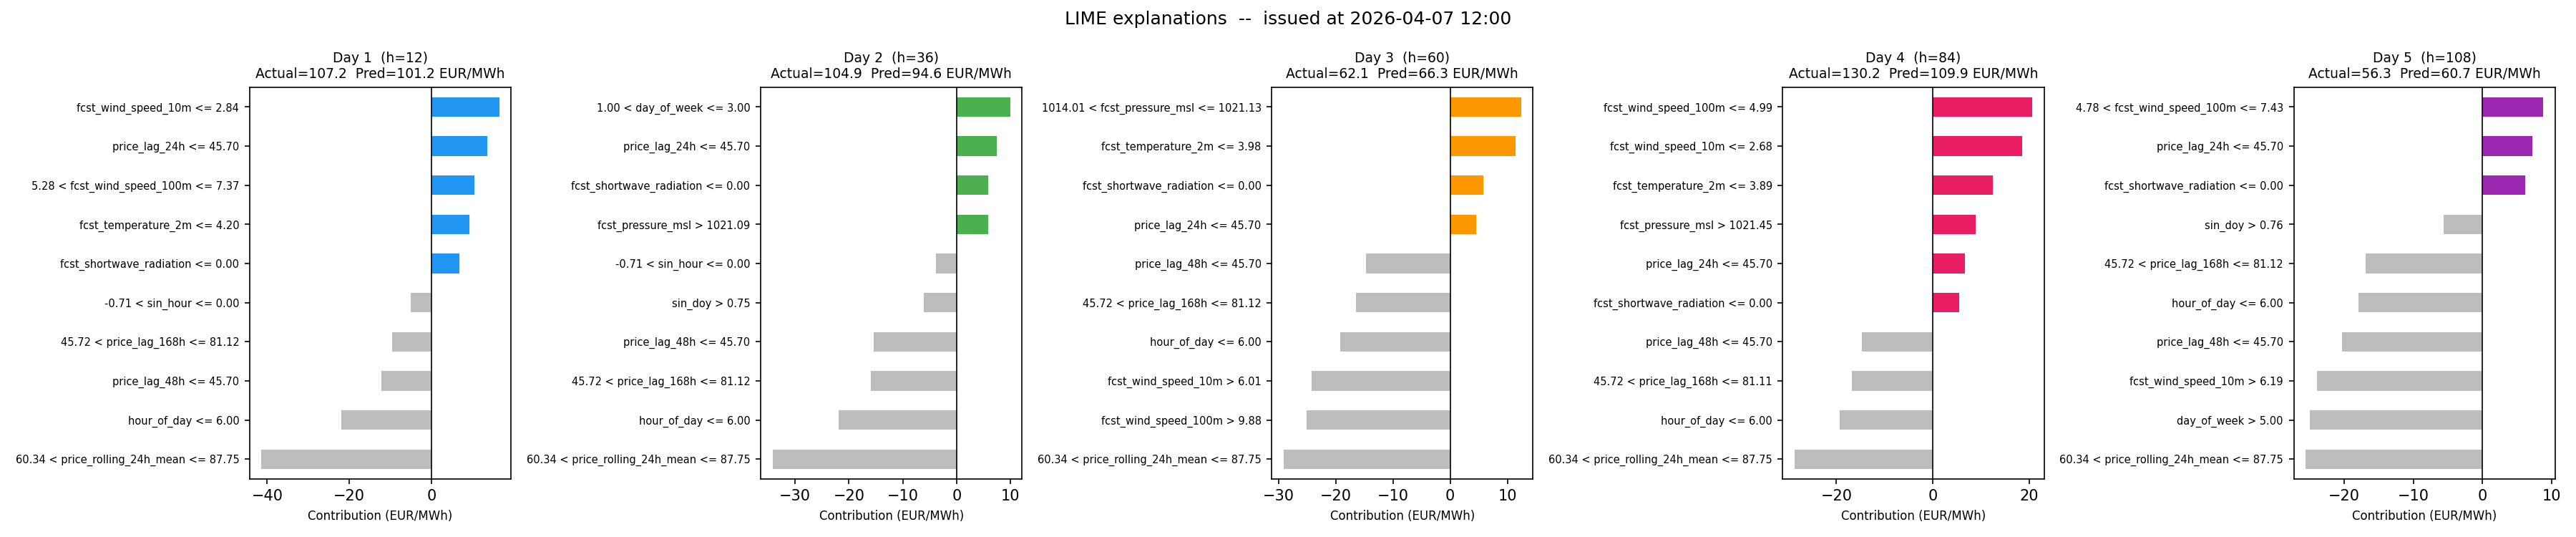

In [14]:
plot_lime_explanations(width=1200)


LIME complements SHAP by focusing on one concrete forecast issue time. It fits a simple local surrogate around the selected forecast instance and shows which features pushed that specific prediction upward or downward. In other words, SHAP answers "what generally drives this model?", while LIME helps answer "why did the model make this recommendation now?"

This local view is important for a consumer recommendation system because the same global model can produce different advice on different days. On one day, the recommended cheap window may be explained by strong wind and low recent prices. On another, a warning to consume earlier may be explained by lower renewable availability, higher lagged prices, and a peak-hour calendar effect.

This also matters for the final impact analysis. The shifting simulation estimates what happens when households react to forecast-based recommendations. XAI does not prove that the behavioral impact will occur, but it makes the mechanism more credible: the simulated shifts are based on price signals that can be inspected and related back to recognizable market drivers. If the impact model shows large benefits while SHAP or LIME reveals that the forecast signal is driven by an implausible artifact, that would be a warning sign before interpreting the resilience contribution.

After retraining the XGBoost models, the XAI artifacts and dashboard SHAP files should be refreshed with `python src/analysis/explainable_ai.py`.


## User dashboard: Household Recommendations

Forecasts alone are not enough for most households. A table of predicted prices is technically useful, but it does not automatically answer the practical question: **Should I run this flexible load now or later?**

The Streamlit dashboard in `dashboard.py` translates the 120-hour forecast state into daily outlooks, cheap windows, historical context, and household-oriented advice. The XAI outputs from the previous section support this step by making the forecast more inspectable: feature importance and SHAP are shown as model insight panels, while LIME-style local explanations can be used to audit individual recommendations when the model suggests waiting, consuming earlier, or shifting demand into a cheaper period.


In [ ]:
from src.analysis.forecast_analysis import preview_recommendation_workflow  # placeholder

preview_recommendation_workflow()


This step connects analytics to behavior. The recommendation does not require the household to understand residual uncertainty, XGBoost, or electricity-market dynamics. Instead, it communicates whether waiting is expected to be valuable and whether an upcoming period looks unusually expensive.

For a real deployment, the forecast table would be produced by the trained price model. In this notebook draft, the same recommendation functions are demonstrated with a forecast-like table so the logic is visible and easy to inspect.

## Modelling of impact: Rolling 120 hour energy shift heuristic

The previous sections established two things that are needed before impact can be measured. First, the dashboard turns the forecast into household-facing recommendations. Second, the XGBoost model provides the hourly 120-hour price outlook that tells the heuristic when it is attractive to wait and when it is better to consume now.

This section connects those two pieces to the resilience question. The goal is to estimate whether forecast-guided shifting changes the timing of household demand enough to reduce pressure in stressed hours, not just whether it saves money for one household. In other words, the end goal is to translate the forecast into a system-impact estimate.

### Energy shift heuristic

The heuristic starts from the hourly system load and splits out the household share. Inside that household block, the model works with four behavioral segments: inflexible demand, wet loads, thermal demand, and EV charging. Each flexible segment has its own share of household load, its own maximum shiftable share, and its own waiting limit.

For every issue time, the model looks ahead 120 hours. Hour by hour, it compares the current hour with future candidate hours inside the segment's allowed waiting window. Candidate hours with lower predicted prices receive a better score, while longer waiting times are penalized. A shift is only accepted if the target hour improves the score and if the move stays within the segment's historical capacity in the receiving hour.

The heuristic therefore does not assume perfect flexibility. It keeps part of each segment fixed, limits how much energy can be moved, and prevents the simulation from pushing too much demand into one cheap hour.

### 90-day simulation of shifted consumption

After the heuristic is defined, we simulate its effect hour for hour. For each selected issue time, the model decides what flexible energy to keep, what to move out of the current hour, and where to place it within the next 120 hours. The outputs are shifted household load, shifted system load, realized energy movement, and cost-based summary metrics.

To keep the impact section aligned with the forecasting evaluation, the simulation is run over the last 90 days. This is the same time span used as the final forecast test period. Because each forecast covers five days, we use non-overlapping 120-hour windows so that the 90-day impact estimate is not double-counting the same hours.

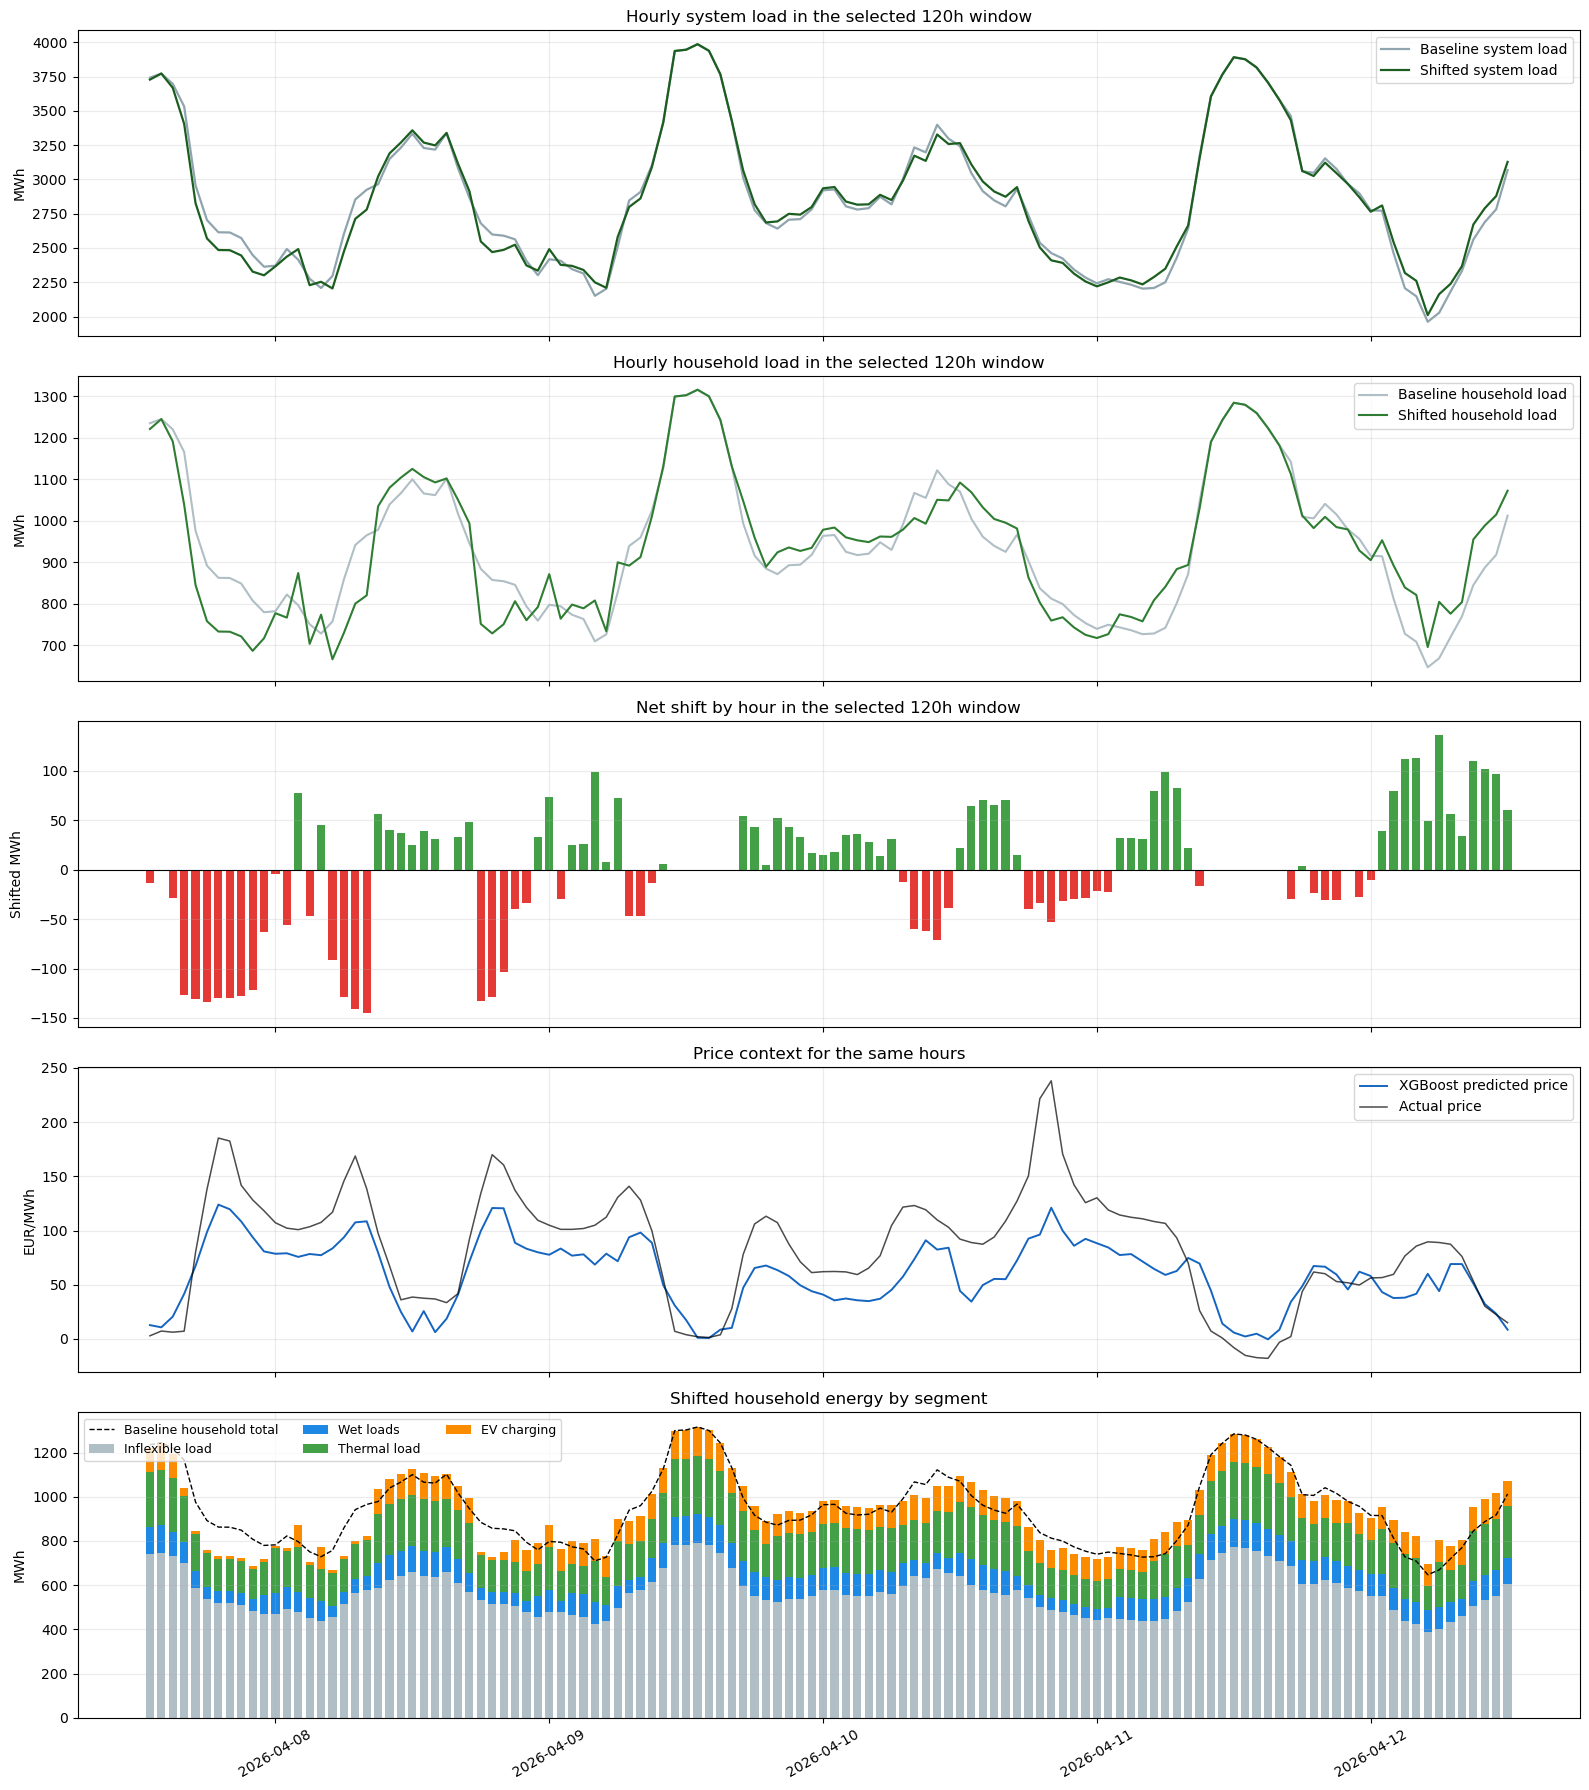

In [ ]:
from src.analysis.impact_analysis import run_granular_shift_illustration

granular_result = run_granular_shift_illustration()
# display(granular_result["summary"].to_frame("value"))

The five-panel figure shows that the heuristic changes the timing of energy consumption depending on the energy price. The baseline and shifted curves stay close overall, which is exactly what we want: the model is not removing demand, it is redistributing it. The net-shift panel makes this especially clear, because hours with reduced demand are balanced by hours with added demand later in the window.

The segment panel also shows that the behavior is not driven by one perfectly flexible block. Instead, the shifts are distributed across the flexible segments, while the inflexible part remains anchored in place.

While the five-panel illustration above shows one 120-hour decision window in detail, we also eant to understand whether the same pattern repeats across the evaluation period. The next figure aggregates the 90-day simulation into an average net-shift heatmap by hour of day and day of week.

Negative values indicate hours where load is typically moved away from the original slot, while positive values indicate hours that tend to receive shifted demand.

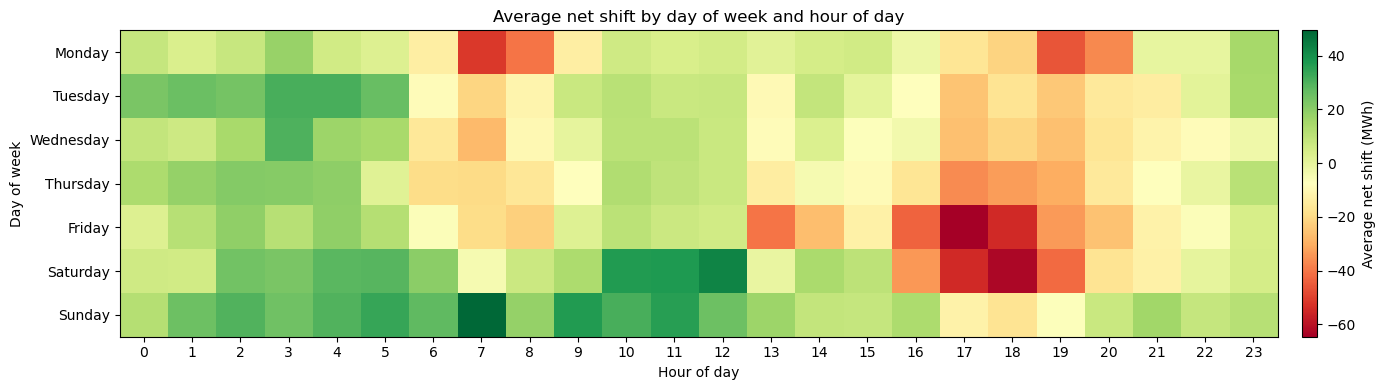

In [ ]:
from src.analysis.impact_analysis import (
    plot_average_net_shift_heatmap,
    run_90_day_impact_simulation,
)

impact_90d = run_90_day_impact_simulation(simulation_days=90)
heatmap_df, _, _ = plot_average_net_shift_heatmap(impact_90d["profiles"])

The heatmap indicates a stable weekly timing pattern rather than random movement. The strongest negative values are concentrated in late afternoon and early evening hours, especially on Friday and Saturday, which means the heuristic consistently pulls load away from periods that appear more expensive and system-stressed. In contrast, the strongest positive values are concentrated in early Sunday and late-morning weekend hours, showing where the model tends to reallocate that demand.

This is an important result because it suggests the heuristic does not simply spread demand evenly across all future hours. It selectively shifts demand away from recurring high-pressure hours and into a smaller set of repeatedly attractive hours. That makes the behavior interpretable: the model learns a recognizable rhythm of when households should wait and when they can safely consume.

The heatmap shows whether the heuristic creates a stable timing pattern rather than isolated shifts. If the same hours repeatedly lose demand while other hours repeatedly absorb it, the heuristic is not just reacting to one unusual week. It is creating a repeatable temporal redistribution of demand.

The last figure in this section turns that timing pattern into a peak-impact measure. The waterfall compares cumulative load above the historical p95 threshold before and after shifting, both for total household demand and for the full system load.

,baseline_p95_mwh,current_above_p95_mwh,impact_mwh,shifted_above_p95_mwh,peak_reduction_pct,current_hours_above_p95,shifted_hours_above_p95
case,,,,,,,
Total household,1101.47,86932.71,2614.02,84318.69,3.01,877,873
Total system energy,3337.78,263432.46,3887.42,259545.03,1.48,877,875


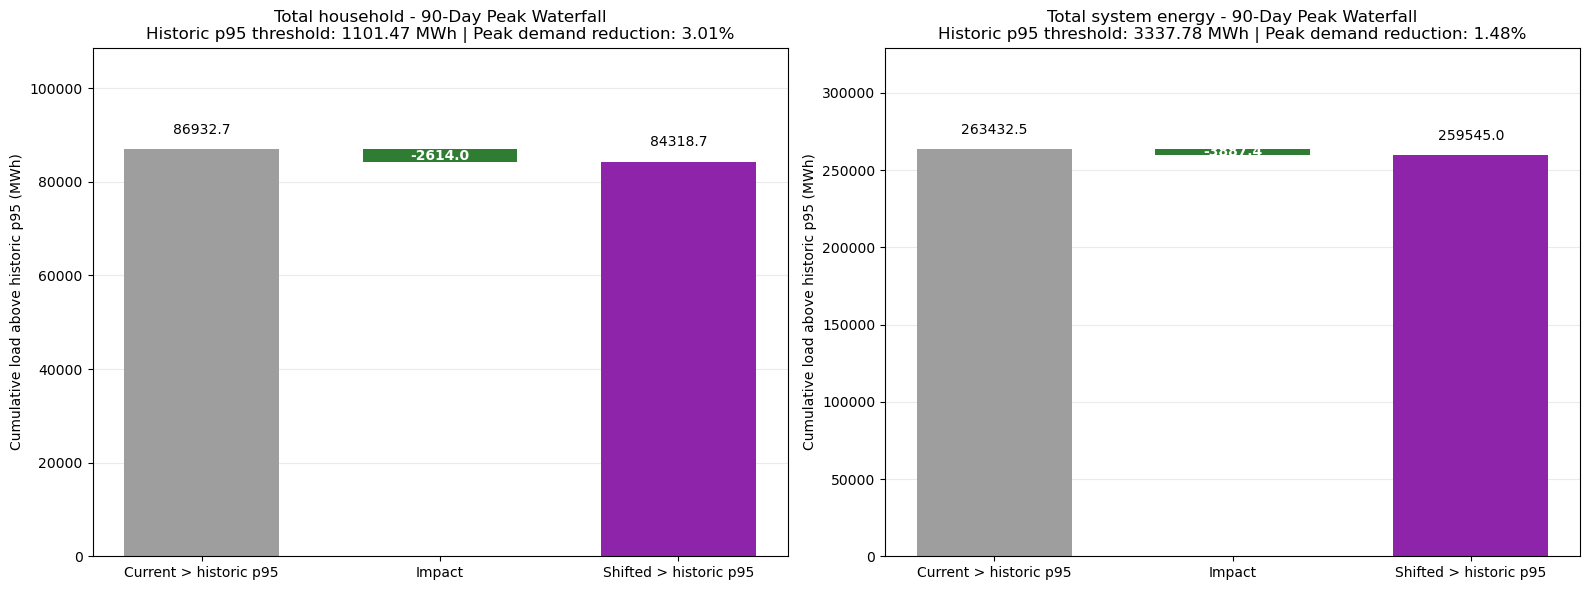

In [ ]:
from src.analysis.impact_analysis import plot_peak_excess_waterfalls

peak_summary_df, _, _ = plot_peak_excess_waterfalls(
    impact_90d["profiles"],
    impact_90d["system_load"],
)
display(
    peak_summary_df.assign(
        baseline_p95_mwh=lambda df: df["baseline_p95_mwh"].round(2),
        current_above_p95_mwh=lambda df: df["current_above_p95_mwh"].round(2),
        impact_mwh=lambda df: df["impact_mwh"].round(2),
        shifted_above_p95_mwh=lambda df: df["shifted_above_p95_mwh"].round(2),
        peak_reduction_pct=lambda df: df["peak_reduction_pct"].round(2),
    ).set_index("case")
)

**Conclusion from the waterfall plot.**

The waterfall shows that the shifting heuristic reduces excess demand above the historical p95 threshold, but that the effect is moderate rather than dramatic. In the current central scenario, the reduction is stronger for the household part of the load than for the full system, which is expected because the heuristic only controls one share of total demand.

This is still a meaningful takeaway. Even a relatively small percentage reduction at system level implies that forecast-guided household flexibility can shave the most stressed hours without requiring unrealistic behavior from all consumers. The result therefore supports the resilience argument, but it also keeps the conclusion credible: household shifting helps, yet it is not a complete solution on its own.

### Assumptions behind the heuristic

The impact model rests on a small set of transparent assumptions. The most important are the estimated household share of total system demand, the segment split inside household demand, the maximum shiftable share in each segment, and the allowed waiting time before the energy service must still be delivered.

These are scenario choices rather than measured behavioral truths. They define what the heuristic is allowed to move. The tables below therefore should be read as the behavioral boundary of the simulation: if the shiftable shares or waiting windows change, the estimated impact changes as well.

In [1]:
from IPython.display import Markdown, display

from src.analysis.impact_analysis import (
    make_heuristic_assumption_summary,
    make_heuristic_assumption_table,
)

assumption_summary = make_heuristic_assumption_summary()
assumption_table = make_heuristic_assumption_table().copy()

summary_rows = [
    ("Household share of total system load", f"{assumption_summary['household_share_of_system_pct']:.1f}%"),
    ("Flexible share of household load", f"{assumption_summary['flexible_share_of_household_pct']:.1f}%"),
    (
        "Maximum theoretical shiftable share of household load",
        f"{assumption_summary['max_theoretical_shiftable_share_of_household_pct']:.1f}%",
    ),
    (
        "Maximum theoretical shiftable share of total system load",
        f"{assumption_summary['max_theoretical_shiftable_share_of_system_pct']:.1f}%",
    ),
]

summary_md = ["| Assumption | Value |", "|---|---:|"]
for label, value in summary_rows:
    summary_md.append(f"| {label} | {value} |")

display(Markdown("\n".join(summary_md)))

segment_md = [
    "| Segment | Share of household load | Max shiftable share within segment | Max shiftable share of household load | Max wait | Wait penalty |",
    "|---|---:|---:|---:|---:|---:|",
]

for _, row in assumption_table.iterrows():
    segment_md.append(
        "| "
        f"{row['label']} | "
        f"{row['share_of_household_load_pct']:.1f}% | "
        f"{row['max_shiftable_share_pct']:.1f}% | "
        f"{row['max_shiftable_share_of_household_pct']:.1f}% | "
        f"{int(row['max_wait_h'])} h | "
        f"{row['wait_penalty']:.2f} |"
    )

display(Markdown("\n".join(segment_md)))

| Assumption | Value |
|---|---:|
| Household share of total system load | 33.0% |
| Flexible share of household load | 40.0% |
| Maximum theoretical shiftable share of household load | 15.0% |
| Maximum theoretical shiftable share of total system load | 5.0% |

| Segment | Share of household load | Max shiftable share within segment | Max shiftable share of household load | Max wait | Wait penalty |
|---|---:|---:|---:|---:|---:|
| Inflexible load | 60.0% | 0.0% | 0.0% | 0 h | 0.00 |
| Wet loads | 10.0% | 35.0% | 3.5% | 48 h | 0.90 |
| Thermal load | 20.0% | 15.0% | 3.0% | 24 h | 1.20 |
| EV charging | 10.0% | 85.0% | 8.5% | 120 h | 0.35 |

**Conclusion from the assumptions table.**

The assumptions make clear that the model is intentionally conservative. A large share of household demand remains inflexible, and even the flexible segments are only partly movable. EV charging receives the largest flexibility window, while wet loads and thermal demand are more constrained, which reflects the idea that not all energy services can wait equally long.

This matters for the interpretation of the whole impact section. If the model still produces measurable peak reduction under these limits, the result is more credible than if it had been built on near-perfect flexibility. At the same time, the assumptions also define the ceiling of the analysis: stronger flexibility adoption or different segment shares would likely increase the estimated impact.

## Sensitivity analysis: Comparing impact sensitivity of the forecast model

Because the electricity price forecast is uncertain, we include a sensitivity analysis of the simulated grid impact. The question is: how much does the estimated resilience effect change if the forecasted future prices are systematically too low or too high?

This matters because households make shifting decisions based on predicted price differences. If the model underestimates or overestimates future prices, it may recommend too much or too little shifting. Comparing scenarios such as `-10% forecast bias`, `baseline`, and `+10% forecast bias` helps show how accurate the model needs to be for the recommender to support grid resilience reliably.

## Discussion: Resilience Contribution, Assumtions & Limitation


## Conclusion

